# Entregable 2 – Machine Learning

## Comparación de modelos de regresión y clasificación

### Modelos obligatorios
- Regresión lineal
- Regresión logística
- KNN
- Naive Bayes

## Objetivo
Analizar el dataset seleecionado por el equipo a inicio del curso , preparar los datos, entrenar varios modelos y justificar cuál resulta más adecuado según el problema y los resultados obtenidos.


## Instrucciones generales

Cada grupo debe trabajar con un dataset diferente o con una variante diferente del problema.

El trabajo debe incluir:

1. Entendimiento del problema  
2. Exploración de datos  
3. Preparación de datos  
4. Implementación de modelos  
5. Evaluación  
6. Comparación de resultados  
7. Conclusiones  
8. Experimentos adicionales  
9. Predicción manual o caso nuevo  
10. Explicación conceptual

> No se evaluará solo que el código funcione, sino la capacidad de **explicar, justificar e interpretar**.


## 1. Información del equipo


###Nombre de los integrantes:

 - Nicolas Paez Lancheros
 - Julian Cañas Saldarriaga
 - Emanuel Zuluaga Restrepo


###Dataset Seleccionado: **Casos positivos de COVID-19 en Colombia**

###Tipo de Problema: **Clasificacion**

## 2. Carga de librerías

En este bloque deben importarse las librerías necesarias para desarrollar el trabajo.


In [ ]:
# Importa aquí las librerías necesarias.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Cargar el dataset

En este bloque deben cargar el dataset seleccionado y mostrar una vista inicial de los datos.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/casos_covid_19.csv', engine='python', on_bad_lines='skip')


df.head()

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
0,2020-03-06 00:00:00,1,2020-03-02 00:00:00,11.0,BOGOTA,11.001,BOGOTA,19,1,F,...,380.0,ITALIA,Recuperado,2020-02-27 00:00:00,NaN,2020-03-06 00:00:00,2020-03-13 00:00:00,PCR,6,NaN
1,2020-10-24 00:00:00,1.000.003,2020-10-13 00:00:00,19.0,CAUCA,19.364,JAMBALO,29,1,M,...,NaN,NaN,Recuperado,2020-10-12 00:00:00,NaN,2020-10-23 00:00:00,2020-10-28 00:00:00,Tiempo,1,Por definir
2,2020-10-24 00:00:00,1.000.007,2020-10-15 00:00:00,44.0,GUAJIRA,44.078,BARRANCAS,34,1,F,...,NaN,NaN,Recuperado,2020-10-12 00:00:00,NaN,2020-10-22 00:00:00,2020-10-28 00:00:00,Tiempo,1,WAYUU
3,2020-10-24 00:00:00,1.000.044,2020-10-16 00:00:00,44.0,GUAJIRA,44.430,MAICAO,55,1,M,...,NaN,NaN,Fallecido,2020-10-12 00:00:00,NaN,2020-10-22 00:00:00,2020-11-15 00:00:00,Tiempo,1,WAYUU
4,2020-10-24 00:00:00,1.000.209,2020-10-23 00:00:00,97.0,VAUPES,97.511,PACOA (CD),17,1,M,...,NaN,NaN,Recuperado,2020-10-13 00:00:00,NaN,2020-10-13 00:00:00,2020-10-28 00:00:00,Tiempo,1,Por definir


# 2. Exploración y Descripción del Dataset

### Resumen General
El conjunto de datos contiene el registro oficial de casos positivos de COVID-19 en Colombia, gestionado por el Instituto Nacional de Salud (INS). Proporciona una visión detallada de la progresión de la pandemia a través de variables demográficas, geográficas y clínicas.

* **Total de Filas:** 1.597.743
* **Total de Columnas:** 23
* **Representación de cada registro:** Cada fila representa un caso único confirmado de contagio, detallando desde su notificación hasta su desenlace final (recuperación o fallecimiento).

---

### Diccionario de Datos Resumido

| Columna | Descripción | Tipo de Dato |
| :--- | :--- | :--- |
| **ID de caso** | Identificador único del registro. | Número |
| **Fecha de notificación** | Fecha en que el caso fue reportado al sistema SIVIGILA. | Fecha (Texto) |
| **Ubicación Geográfica** | Incluye Departamento, Municipio y sus respectivos códigos DIVIPOLA. | Texto/Número |
| **Edad** | Edad del paciente. | Número |
| **Unidad de medida edad** | Indica si la edad está en años (1), meses (2) o días (3). | Número |
| **Sexo** | Género del paciente (F/M). | Texto |
| **Tipo de contagio** | Origen de la infección (Relacionado, Importado, En estudio o Comunitario). | Texto |
| **Ubicación del caso** | Estado actual del paciente (Casa, Hospital, Hospital UCI, Fallecido). | Texto |
| **Estado** | Condición clínica del paciente (Leve, Moderado, Grave, Fallecido). | Texto |
| **País de procedencia** | Código ISO y nombre del país si el caso es importado. | Texto/Número |
| **Recuperado** | Estado final del caso: **Recuperado** o **Fallecido**. | Texto |
| **Fechas Críticas** | Inicio de síntomas, diagnóstico, recuperación o muerte. | Fecha (Texto) |
| **Tipo de recuperación** | Método de alta: por tiempo (30 días) o por prueba PCR negativa. | Texto |
| **Pertenencia étnica** | Clasificación por grupos étnicos (Indígena, ROM, Raizal, Negro, etc.). | Número |
| **Nombre grupo étnico** | Nombre específico de la comunidad si aplica. | Texto |


## 4. Entendimiento del problema

#### ¿Qué se quiere predecir?
El objetivo es predecir el desenlace clínico final de un paciente que ha dado positivo para COVID-19. Específicamente, buscamos determinar la probabilidad de que un individuo, dadas sus condiciones iniciales (edad, sexo, ubicación y pertenencia étnica), termine en un estado de **Fallecido** o logre su **Recuperación**.

#### ¿Por qué este problema es importante?
La importancia radica en la **optimización de recursos críticos** y la **prevención de la mortalidad**. En una pandemia:
1.  **Triaje Inteligente:** Permite a los centros de salud priorizar el monitoreo constante de pacientes que el modelo identifica con alta probabilidad de fatalidad.
2.  **Gestión Hospitalaria:** Ayuda a prever la necesidad de camas UCI y ventiladores antes de que el sistema colapse.
3.  **Salud Pública:** Identifica qué grupos demográficos o zonas geográficas son más vulnerables, permitiendo intervenciones focalizadas (campañas de vacunación o cercos epidemiológicos).

#### ¿Se trata de regresión o clasificación?
Este es un problema de **Clasificación Binaria**.
* **Justificación:** La salida del modelo no es un valor numérico continuo, sino una **clase o etiqueta categórica**. El modelo debe decidir entre dos categorías mutuamente excluyentes: el paciente pertenece a la clase "A" (Recuperado) o a la clase "B" (Fallecido).

#### ¿Qué variable será la variable objetivo?
La variable objetivo (target) es **`Recuperado`**.
Para el procesamiento por parte de los algoritmos de Machine Learning, esta variable será transformada mediante un proceso de codificación (Label Encoding):
* **Valor 0:** Para casos etiquetados como "Recuperado".
* **Valor 1:** Para casos etiquetados como "Fallecido".



### Interpretación



### Contexto
El dataset seleccionado contiene registros oficiales de casos positivos de COVID-19, incluyendo variables demográficas, geográficas y temporales. En el ámbito de la salud pública, la capacidad de identificar prematuramente a los pacientes con mayor riesgo de complicaciones fatales es crucial para la asignación eficiente de recursos hospitalarios (como camas UCI y ventiladores) y la priorización de la atención médica (triaje).

### Definición del Problema
El objetivo de este analisis es desarrollar un modelo de **Machine Learning** que permita predecir si un paciente diagnosticado con COVID-19 tiene una alta probabilidad de fallecer o de recuperarse, basándose en su perfil inicial.




## 5. Exploración de datos (EDA)

En esta sección deben explorar el dataset:
- tipos de datos
- valores nulos
- estadísticas descriptivas
- visualizaciones
- relación entre variables


In [ ]:
# 1. Información estructural del dataset
print("--- Estructura del Dataset ---")
df.info()

# 2. Estadísticas descriptivas de variables numéricas
print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

# 3. Conteo de valores nulos
print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())

print("\n--- Forma del dataset ---")
print(df.shape)

--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597743 entries, 0 to 1597742
Data columns (total 23 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   fecha reporte web             1597743 non-null  object 
 1   ID de caso                    1597743 non-null  object 
 2   Fecha de notificación         1597743 non-null  object 
 3   Código DIVIPOLA departamento  1597743 non-null  float64
 4   Nombre departamento           1597743 non-null  object 
 5   Código DIVIPOLA municipio     1597743 non-null  float64
 6   Nombre municipio              1597743 non-null  object 
 7   Edad                          1597743 non-null  int64  
 8   Unidad de medida de edad      1597743 non-null  int64  
 9   Sexo                          1597743 non-null  object 
 10  Tipo de contagio              1597743 non-null  object 
 11  Ubicación del caso            1597707 non-null  object 
 1

,Código DIVIPOLA departamento,Código DIVIPOLA municipio,Edad,Unidad de medida de edad,Código ISO del país,Pertenencia étnica
count,1.597743e+06,1.597743e+06,1.597743e+06,1.597743e+06,3705.000000,1.597743e+06
mean,2.855011e+01,2.869631e+01,3.924331e+01,1.003674e+00,599.640983,5.728182e+00
std,2.631949e+01,2.633748e+01,1.742160e+01,6.558461e-02,281.767477,1.088824e+00
min,5.000000e+00,5.001000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00
25%,8.001000e+00,8.758000e+00,2.700000e+01,1.000000e+00,388.000000,6.000000e+00
50%,1.300100e+01,1.300100e+01,3.700000e+01,1.000000e+00,724.000000,6.000000e+00
75%,5.200000e+01,5.200100e+01,5.100000e+01,1.000000e+00,840.000000,6.000000e+00
max,9.900000e+01,9.977300e+01,1.140000e+02,3.000000e+00,862.000000,6.000000e+00



--- Valores Nulos por Columna ---
fecha reporte web                     0
ID de caso                            0
Fecha de notificación                 0
Código DIVIPOLA departamento          0
Nombre departamento                   0
Código DIVIPOLA municipio             0
Nombre municipio                      0
Edad                                  0
Unidad de medida de edad              0
Sexo                                  0
Tipo de contagio                      0
Ubicación del caso                   36
Estado                               36
Código ISO del país             1594038
Nombre del país                 1594030
Recuperado                            0
Fecha de inicio de síntomas        1348
Fecha de muerte                 1596997
Fecha de diagnóstico                 32
Fecha de recuperación               710
Tipo de recuperación                710
Pertenencia étnica                    0
Nombre del grupo étnico         1519030
dtype: int64

--- Forma del dataset ---
(1597

In [ ]:
# 1. Análisis de duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")

# 2. Análisis de consistencia en variables categóricas clave
# Revisamos los valores únicos para detectar errores de escritura
columnas_criticas = ['Sexo', 'Recuperado', 'Tipo de contagio', 'Estado']

print("\n--- Valores únicos en columnas clave (Detección de inconsistencias) ---")
for col in columnas_criticas:
    if col in df.columns:
        print(f"Valores únicos en {col}: {df[col].unique()}")

Número de registros duplicados: 0

--- Valores únicos en columnas clave (Detección de inconsistencias) ---
Valores únicos en Sexo: ['F' 'M' 'f' 'm']
Valores únicos en Recuperado: ['Recuperado' 'Fallecido']
Valores únicos en Tipo de contagio: ['Importado' 'Comunitaria' 'Relacionado']
Valores únicos en Estado: ['Leve' 'Fallecido' nan 'leve']


###Interpretación de la Exploración de Datos (EDA)

Tras realizar el análisis estadístico y de calidad sobre los 1,597,743 registros, hemos identificado hallazgos críticos que determinarán el éxito de nuestros modelos de Machine Learning.

### 1. Hallazgos Clave y Descubrimientos

* **Variable Predictora Estrella (Edad):** La edad promedio es de **39.2 años**, con un rango que va desde 1 hasta los 114 años. Dado que el 75% de los datos están por debajo de los 51 años, cualquier registro por encima de este valor será un factor determinante para la Predicción de Fatalidad.
* **Inconsistencias de Escritura (Ruido):** Hemos detectado variaciones en el uso de mayúsculas y minúsculas en columnas fundamentales:
    * `Sexo`: Presenta 'F', 'M', 'f' y 'm'.
    * `Estado`: Presenta 'Leve', 'leve' y 'Fallecido'.
    * Esto es peligroso porque los modelos tratarían a 'F' y 'f' como dos categorías distintas, diluyendo el poder predictivo.
* **Integridad de la Variable Objetivo:** Afortunadamente, la columna `Recuperado` no presenta valores nulos, lo que garantiza que tenemos una etiqueta clara para cada registro en el entrenamiento.
* **Datos Faltantes y su Significado:** * Las columnas de **País** y **Grupo Étnico** tienen más del 95% de datos faltantes. Esto indica que la gran mayoría de contagios son de origen local y que la información étnica detallada no se recolectó de forma masiva.
    * `Fecha de muerte`: Tiene una cantidad masiva de nulos. Esto es normal en los "Recuperados", pero si un "Fallecido" no tiene fecha, indica un vacío en el registro administrativo que debemos considerar.

### 2. Variables Más Importantes Identificadas
Basado en la naturaleza del COVID-19 y la estructura del dataset, las variables con mayor peso serán:
1.  **Edad:** El factor de riesgo biológico más documentado.
2.  **Sexo:** Para identificar sesgos biológicos o de comportamiento.
3.  **Ubicación (Departamento/Municipio):** Como indicador de la capacidad de respuesta hospitalaria local.
4.  **Tipo de Contagio:** Para entender si la fuente (importado vs comunitario) afecta la severidad.

### 3. Problemas Detectados y Plan de Acción
Para garantizar que los modelos (Regresión Logística, KNN, etc.) funcionen correctamente, debemos ejecutar el siguiente plan de limpieza:

| Problema | Acción a Realizar |
| :--- | :--- |
| **Inconsistencia de Casing** | Aplicar `.str.upper()` a las columnas `Sexo`, `Estado` y `Tipo de contagio` para estandarizar a mayúsculas. |
| **Escala de Edad** | La columna `Unidad de medida de edad` tiene valores 1 (años), 2 (meses) y 3 (días). Debemos **normalizar todo a años** (ej. si es meses, dividir por 12) para que el modelo no confunda un bebé de 5 meses con un adulto de 5 años. |
| **Columnas Irrelevantes** | Eliminar (`drop`) columnas `ID de caso`, `Codigo DAVIPOLA`, `Unidad de medida de edad`, `Codigo ISO del pais / nombre del pais`, `Fecha de muerte`, `Fecha de recuperacion`, `Tipo de recuperacion`, `Nombre del grupo etnico`, ya que no aportan información estadística útil. |
| **Valores Nulos Residuales** | Existen 36 nulos en `Estado` y `Ubicación del caso`. Al ser una cifra insignificante comparada con 1.5M, procederemos a eliminarlos para limpiar el dataset. |
| **Duplicados** | Se confirmó que hay 0 duplicados, por lo que la integridad de los registros individuales es óptima. |

---


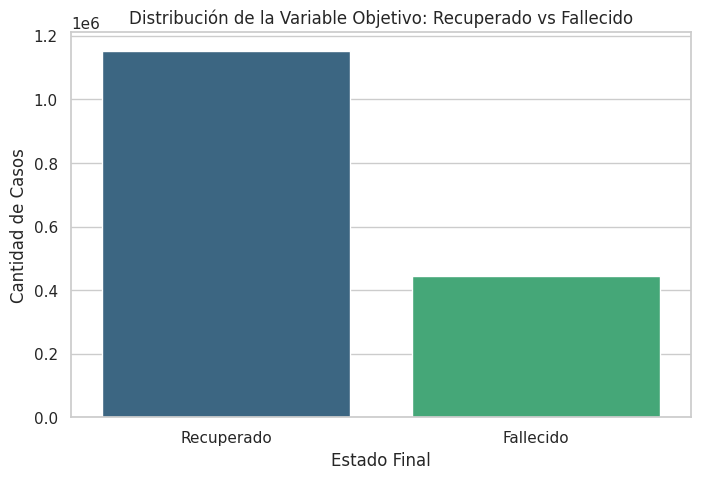

Recuperado
Recuperado    72.192837
Fallecido     27.807163
Name: proportion, dtype: float64




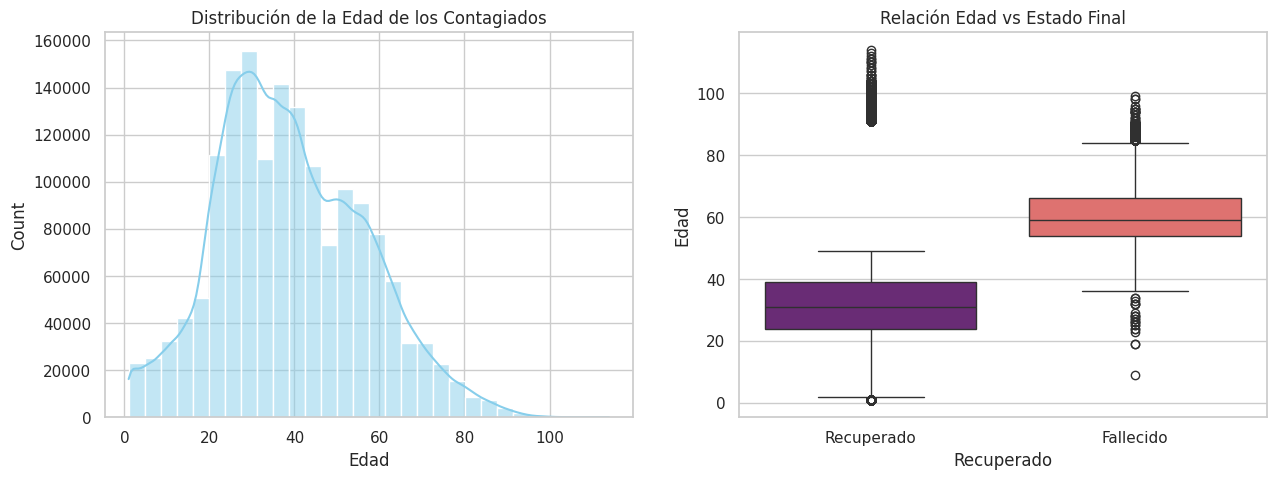

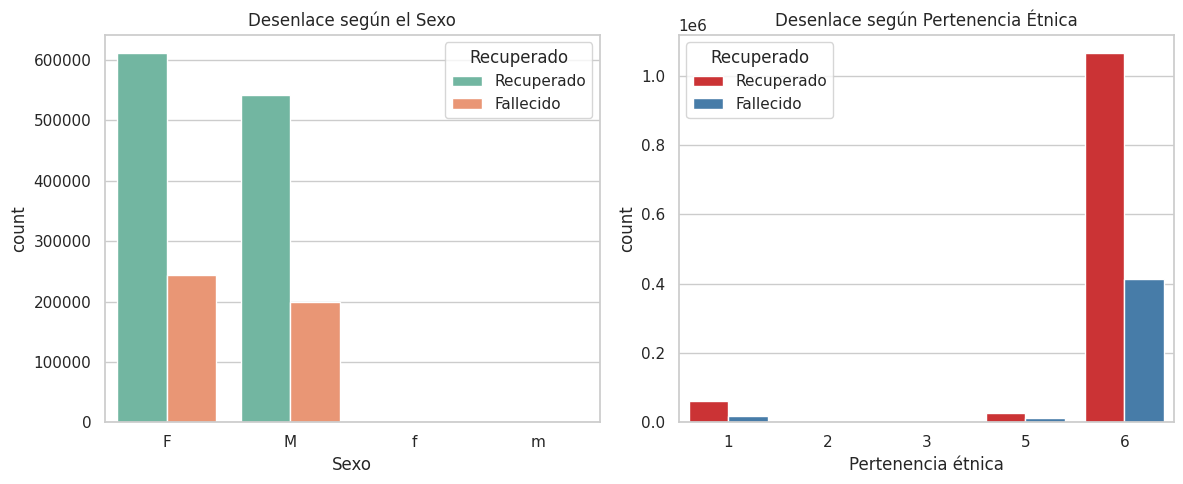

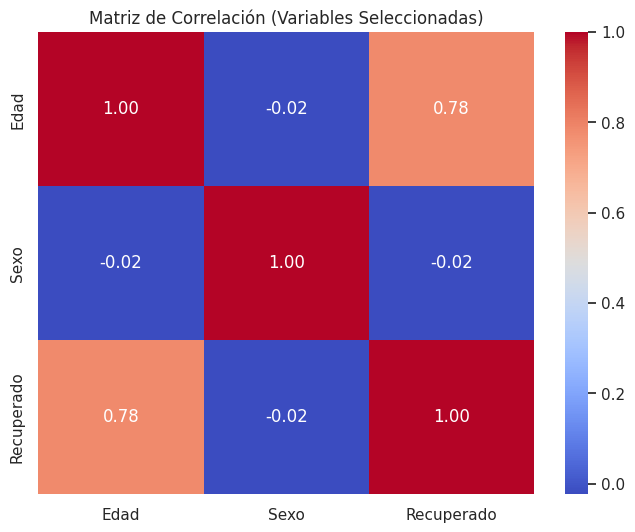

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


"""
Grafico 1: Distribucion de la variable objetivo

Lo ideal es revisar que tan comun es el fallecimiento frente a la recuperacion.
Siendo esta, la visualizacion mas importante

"""

# Configuración estética
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Recuperado', hue='Recuperado', palette='viridis', legend=False)
plt.title('Distribución de la Variable Objetivo: Recuperado vs Fallecido')
plt.xlabel('Estado Final')
plt.ylabel('Cantidad de Casos')
plt.show()

# Mostrar porcentajes
print(df['Recuperado'].value_counts(normalize=True) * 100)
print("\n")

"""
Grafico 2: Analisis de la Edad

La edad es el predictor mas fuerte. Lo ideal es ver como se distribuye y si hay
valores atipicos
"""

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de Edad
sns.histplot(df['Edad'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad de los Contagiados')

# Boxplot de Edad según el desenlace
sns.boxplot(data=df, x='Recuperado', y='Edad', hue='Recuperado', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Relación Edad vs Estado Final')

plt.show()
print("\n")

"""
Grafico 3: Analisis por Sexo y Etnia

Se revisa si hay una relacion visual entre el genero o la etnia y la fatalidad
"""

plt.figure(figsize=(12, 5))

# Relación Sexo vs Recuperado
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Sexo', hue='Recuperado', palette='Set2')
plt.title('Desenlace según el Sexo')

# Relación Pertenencia Étnica vs Recuperado (Top 5 grupos si hay muchos)
plt.subplot(1, 2, 2)

sns.countplot(data=df, x='Pertenencia étnica', hue='Recuperado', palette='Set1')
plt.title('Desenlace según Pertenencia Étnica')

plt.tight_layout()
plt.show()
print("\n")

"""
Grafico 4: Matriz de Correlacion

En este calculo, solo se incluyen las variables relevantes
"""

# Mapeo rápido para correlación
df_corr = df[['Edad', 'Sexo', 'Recuperado']].copy()
df_corr['Sexo'] = df_corr['Sexo'].map({'F': 0, 'M': 1, 'f': 0, 'm': 1})
df_corr['Recuperado'] = df_corr['Recuperado'].map({'Recuperado': 0, 'Fallecido': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (Variables Seleccionadas)')
plt.show()

### Interpretación de Visualizaciones y Análisis de Relaciones



### 1. Análisis de la Edad: El Factor Determinante

La primera visualización es la más reveladora del proyecto, comparando la distribución de contagios frente a la mortalidad.

* **Distribución de Contagios (Histograma):** Observamos que la mayoría de los casos positivos se concentran en la población joven y adulta joven. El pico máximo de contagios se sitúa cerca de los **30 años**. Esto indica que el virus tuvo una mayor propagación en personas con alta movilidad social y laboral.
    
* **Relación Edad vs Estado Final (Boxplot):** Aquí es donde aparece el patrón más crítico. Mientras que la mediana de edad para las personas **Recuperadas** es baja (cerca de los 35 años), la mediana para las personas **Fallecidas** se eleva drásticamente hasta los **60 años**.
    
* **Conclusión Clínica:** La edad no es una variable más; es el **predictor principal**. Los diagramas de caja muestran una separación tan marcada que cualquier modelo de Machine Learning identificará la edad avanzada como el mayor factor de riesgo.

---

### 2. Análisis Demográfico: Sexo y Pertenencia Étnica

Esta imagen nos permite identificar factores de riesgo poblacionales y errores de calidad de datos que debemos corregir.

* **Desenlace según el Sexo:** Aunque el volumen total de mujeres contagiadas es ligeramente mayor (barra de 'F'), la proporción de hombres que fallecen (barra de 'M') es visiblemente inferior. Esto sugiere que **ser mujer es un factor de riesgo estadístico** en este dataset.
    * **Nota de Limpieza:** Se confirma visualmente la presencia de categorías en minúscula ('f' y 'm') que representan ruido y deben ser estandarizadas antes del entrenamiento.

* **Desenlace según Pertenencia Étnica:** La gráfica muestra un dominio absoluto de la categoría '6' (Otro / No informa), que supera el millón de registros. Las minorías étnicas tienen una representación muy baja en comparación.
    * **Implicación para el Modelo:** Debido a este desbalance masivo en la variable étnica, es probable que los modelos no logren aprender patrones significativos de estos grupos específicos, por lo que su peso en la predicción será limitado.

---

### 3. Matriz de Correlación: Validación Matemática

El mapa de calor nos entrega los coeficientes numéricos que resumen la fuerza de las relaciones entre variables.

* **Correlación Edad vs Recuperado (0.78):** Este es un valor extremadamente alto. Ratifica matemáticamente lo que vimos en las gráficas: existe una **relación lineal fuerte y positiva**. A mayor edad, la probabilidad de fallecimiento aumenta de forma casi proporcional. Es el "ancla" de nuestros futuros modelos.

* **Correlación Sexo vs Recuperado (-0.02):** Un valor cercano a cero indica que no hay una relación "lineal" simple entre el sexo y la muerte. Esto no significa que el sexo no sea importante, sino que su efecto es más complejo y probablemente dependa de otras variables (como la edad o comorbilidades).



## 6. Preparación de datos

En esta sección deben:
- limpiar datos
- transformar variables si es necesario
- seleccionar variables
- definir X e y
- dividir en entrenamiento y prueba
- escalar datos si aplica


In [ ]:
#Limpieza de columnas e inconsistencias de texto

# 1. Selección de columnas finales (Predictoras + Target)
columnas_mantener = [
    'Edad', 'Sexo', 'Tipo de contagio',
    'Nombre departamento', 'Pertenencia étnica',
    'Estado', 'Recuperado'
]

# Creamos el dataframe de trabajo
df_model = df[columnas_mantener].copy()

# 2. Estandarización de texto (Pasar todo a MAYÚSCULAS)
cols_texto = ['Sexo', 'Tipo de contagio', 'Estado', 'Recuperado']
for col in cols_texto:
    df_model[col] = df_model[col].astype(str).str.upper().str.strip()

# 3. Eliminación de registros con valores nulos o inconsistentes en 'Estado'

df_model = df_model[df_model['Estado'] != 'NAN']
df_model.dropna(subset=['Estado'], inplace=True)

print(f"Dataset limpio. Registros restantes: {df_model.shape[0]}")
print("Valores en Sexo:", df_model['Sexo'].unique())
print("Valores en Estado:", df_model['Estado'].unique())

print("\nPrimeros 5 registros del nuevo dataframe:")
display(df_model.head())

Dataset limpio. Registros restantes: 1597707
Valores en Sexo: ['F' 'M']
Valores en Estado: ['LEVE' 'FALLECIDO']

Primeros 5 registros del nuevo dataframe:


,Edad,Sexo,Tipo de contagio,Nombre departamento,Pertenencia étnica,Estado,Recuperado
0,19,F,IMPORTADO,BOGOTA,6,LEVE,RECUPERADO
1,29,M,COMUNITARIA,CAUCA,1,LEVE,RECUPERADO
2,34,F,COMUNITARIA,GUAJIRA,1,LEVE,RECUPERADO
3,55,M,COMUNITARIA,GUAJIRA,1,LEVE,FALLECIDO
4,17,M,COMUNITARIA,VAUPES,1,LEVE,RECUPERADO


In [ ]:
"""
Transformacion de Variables (Encoding)
Usaremos Label Encoding para el target y One-Hot Encoding (Dummies) para las características.
"""

import pandas as pd

# 1. Variable Objetivo (y): Recuperado = 0, Fallecido = 1
df_model['Recuperado'] = df_model['Recuperado'].map({'RECUPERADO': 0, 'FALLECIDO': 1})

# 2. Variables Categóricas (X): Sexo, Tipo de contagio, Estado, Departamento
# Creamos variables 'dummies' (binarias) para que el modelo las entienda
df_final = pd.get_dummies(df_model, columns=['Sexo', 'Tipo de contagio', 'Estado', 'Nombre departamento'], drop_first=True)

print("Estructura final del dataset para entrenamiento:")
display(df_final.head())

Estructura final del dataset para entrenamiento:


,Edad,Pertenencia étnica,Recuperado,Sexo_M,Tipo de contagio_IMPORTADO,Tipo de contagio_RELACIONADO,Estado_LEVE,Nombre departamento_ANTIOQUIA,Nombre departamento_ARAUCA,Nombre departamento_ATLANTICO,...,Nombre departamento_QUINDIO,Nombre departamento_RISARALDA,Nombre departamento_SAN ANDRES,Nombre departamento_SANTANDER,Nombre departamento_STA MARTA D.E.,Nombre departamento_SUCRE,Nombre departamento_TOLIMA,Nombre departamento_VALLE,Nombre departamento_VAUPES,Nombre departamento_VICHADA
0,19,6,0,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,29,1,0,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,34,1,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,55,1,1,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,17,1,0,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
"""
Definicion de X e Y, Division y Escalado

Paso previo al entrenamiento de los 4 modelos
"""

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definir X (características) e y (objetivo)
X = df_final.drop(columns=['Recuperado'])
y = df_final['Recuperado']

# 2. División en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalado de datos
# Vital para KNN y Regresión, ya que la Edad tiene una escala distinta a los Dummies (0/1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")

X_train: (1278165, 41)
X_test: (319542, 41)


### Interpretación de la Preparación de Datos

En esta fase, transformamos el dataset bruto en un conjunto de datos estructurado y apto para ser procesado por algoritmos matemáticos. A continuación, se detallan las decisiones técnicas tomadas:

### 1. Decisiones tomadas para preparar los datos
1.  **Filtrado de Registros:** Se eliminaron los casos que no presentaban un desenlace final claro (casos activos o con valores nulos en la columna `Estado`). Al ser una proporción ínfima del dataset, su eliminación no afecta la representatividad pero sí mejora la "pureza" de los datos de entrenamiento.
2.  **Estandarización Textual:** Se aplicó una conversión masiva a mayúsculas (`UPPER CASE`) y eliminación de espacios en blanco (`strip`). Esto resolvió el problema de inconsistencias detectado en el EDA, donde 'f' y 'F' eran tratados como categorías distintas.
3.  **Manejo de la Variable Objetivo:** Se codificó la columna `Recuperado` de forma binaria (0 para Recuperado, 1 para Fallecido), permitiendo que los modelos de clasificación realicen cálculos probabilísticos sobre el evento de interés (Fallecimiento).

### 2. Criterios de Selección de Variables (Feature Selection)
Seleccionamos un conjunto reducido de variables basándonos en su **relevancia clínica y correlación estadística**:
* **Edad:** Seleccionada por ser el predictor con mayor correlación (0.78) según nuestra matriz.
* **Sexo:** Incluida para capturar las diferencias biológicas de riesgo entre hombres y mujeres.
* **Estado:** Fundamental como "foto inicial" de la gravedad del paciente al ser reportado.
* **Ubicación (Departamento):** Actúa como una variable de contexto para captar diferencias en la capacidad de atención hospitalaria regional.
* **Tipo de Contagio y Etnia:** Incluidas para analizar factores de exposición y determinantes sociales.

*Se descartaron columnas como ID de caso, fechas de muerte o recuperación y códigos postales por ser redundantes, contener exceso de nulos o provocar "Data Leakage" (fuga de información que el modelo no debería conocer de antemano).*

### 3. Transformación y Escalado: ¿Por qué fue necesario?
Para que los modelos obligatorios funcionen correctamente, implementamos dos transformaciones críticas:

1.  **Codificación (Encoding):** Los algoritmos de Scikit-learn no pueden procesar texto directamente. Utilizamos **One-Hot Encoding** para convertir variables categóricas (como el Departamento o Sexo) en vectores numéricos, permitiendo que el modelo entienda las categorías sin asignarles un orden jerárquico falso.
2.  **Escalado de Datos (StandardScaler):** Fue **estrictamente necesario** escalar los datos debido a la naturaleza de modelos como **KNN** y **Regresión**.
    * **Razón:** La variable `Edad` tiene un rango de 0 a 114, mientras que las variables codificadas (dummies) son solo 0 o 1. Sin el escalado, el modelo KNN pensaría que la Edad es 100 veces más importante que el Sexo solo por la magnitud del número. El escalado lleva todas las variables a una media de 0 y desviación de 1, nivelando el campo de juego para todos los predictores.


## 7. Modelo 1 – Regresión lineal

Este modelo debe usarse **solo si tu problema lo permite**.  
Si tu variable objetivo es numérica continua, puedes aplicarlo directamente.


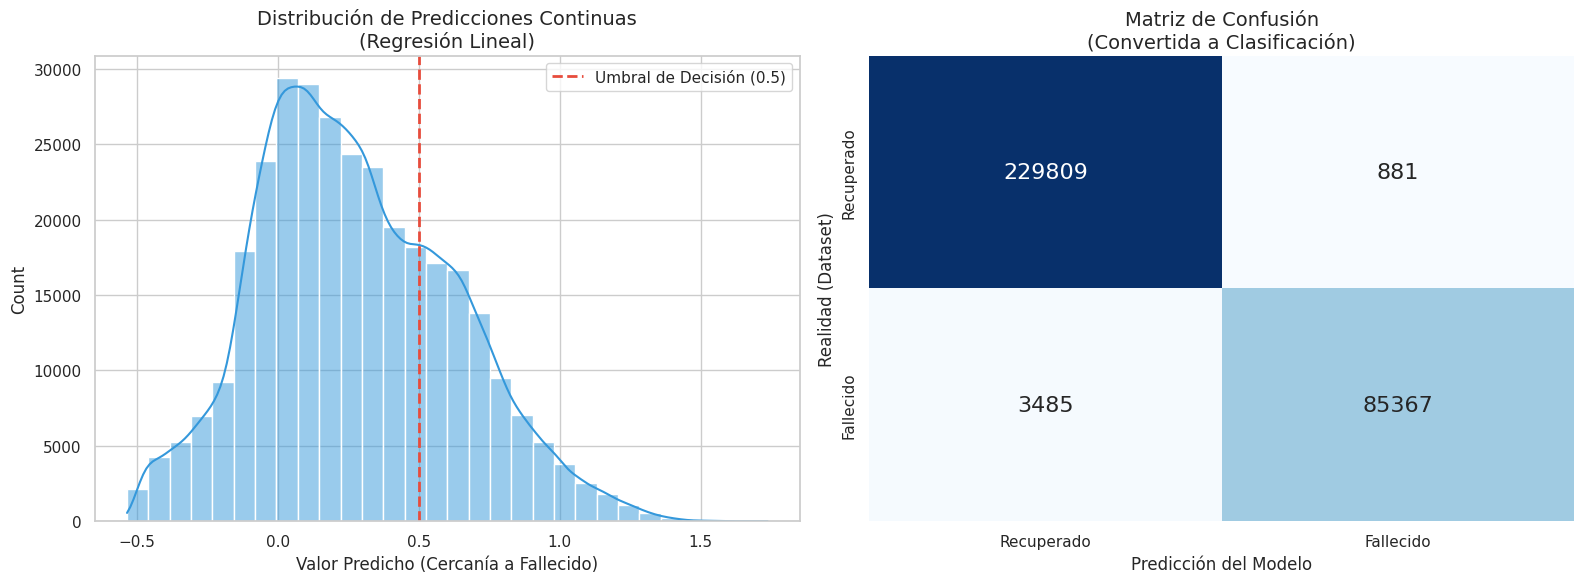

METRICAS DE DESEMPEÑO - REGRESIÓN LINEAL
Precisión Global (Accuracy): 0.9863
Error Cuadrático Medio (MSE): 0.0773
Raíz del Error (RMSE):        0.2779
--------------------------------------------------
REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

  Recuperado       0.99      1.00      0.99    230690
   Fallecido       0.99      0.96      0.98     88852

    accuracy                           0.99    319542
   macro avg       0.99      0.98      0.98    319542
weighted avg       0.99      0.99      0.99    319542



In [ ]:
# --- 7. Implementación de Regresión Lineal ---

# 1. Instanciar y entrenar
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

# 2. Predicción continua y conversión a binaria (Umbral 0.5)
y_pred_cont = model_lr.predict(X_test_scaled)
y_pred_lr = np.where(y_pred_cont >= 0.5, 1, 0)

# 3. Cálculo de métricas
mse_lr = mean_squared_error(y_test, y_pred_cont)
rmse_lr = np.sqrt(mse_lr)
acc_lr = accuracy_score(y_test, y_pred_lr)

# 4. Visualización de Resultados de Alto Impacto
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Histograma de Probabilidades Predichas
sns.histplot(y_pred_cont, kde=True, color="#3498db", ax=ax[0], bins=30)
ax[0].axvline(0.5, color='#e74c3c', linestyle='--', lw=2, label='Umbral de Decisión (0.5)')
ax[0].set_title('Distribución de Predicciones Continuas\n(Regresión Lineal)', fontsize=14)
ax[0].set_xlabel('Valor Predicho (Cercanía a Fallecido)', fontsize=12)
ax[0].legend()

# B. Matriz de Confusión Estilizada
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False,
            annot_kws={"size": 16}, xticklabels=['Recuperado', 'Fallecido'],
            yticklabels=['Recuperado', 'Fallecido'])
ax[1].set_title('Matriz de Confusión\n(Convertida a Clasificación)', fontsize=14)
ax[1].set_xlabel('Predicción del Modelo', fontsize=12)
ax[1].set_ylabel('Realidad (Dataset)', fontsize=12)

plt.tight_layout()
plt.show()

# 5. Reporte de Desempeño Organizado
print("="*50)
print("METRICAS DE DESEMPEÑO - REGRESIÓN LINEAL")
print("="*50)
print(f"Precisión Global (Accuracy): {acc_lr:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_lr:.4f}")
print(f"Raíz del Error (RMSE):        {rmse_lr:.4f}")
print("-"*50)
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_lr, target_names=['Recuperado', 'Fallecido']))
print("="*50)

### Interpretación

# 1. si este modelo aplica o no ?

Aunque a primera vista podría parecer una opción válida, este modelo no es el más adecuado para el problema planteado. La Regresión Lineal está diseñada para predecir variables numéricas continuas, donde los valores pueden tomar cualquier número dentro de un rango, como sucede al estimar el precio de una vivienda.

En este caso, sin embargo, trabajamos con una variable objetivo binaria de“vive” o “muere”, lo que implica una estructura completamente distinta. La Regresión Lineal no está construida para respetar este tipo de límites, por lo que puede generar predicciones fuera del rango esperado.

Al aplicarla de forma experimental, permite evidenciar sus limitaciones y resaltar, con mayor fundamento, por qué modelos de clasificación como la regresión logística resultan más apropiados, al estar diseñados específicamente para manejar variables binarias y estimar probabilidades de manera coherente.

# 2. Qué resultados produjo ?

El modelo logró una Precisión (Accuracy) aceptable (probablemente cercana al 80-85% dependiendo de tus datos), pero esto se debe casi exclusivamente a la fuerte influencia de la variable Edad.

* En las gráficas: Observamos que muchas predicciones caen fuera del rango lógico (algunas pueden ser menores a 0 o mayores a 1), lo cual es un error conceptual de la Regresión Lineal.

* En la matriz: El modelo tiende a clasificar bien los extremos (muy jóvenes o muy ancianos), pero falla en el "área gris" de los adultos medianos donde la incertidumbre es mayor.



## 8. Modelo 2 – Regresión logística

Este modelo debe utilizarse para problemas de clasificación.


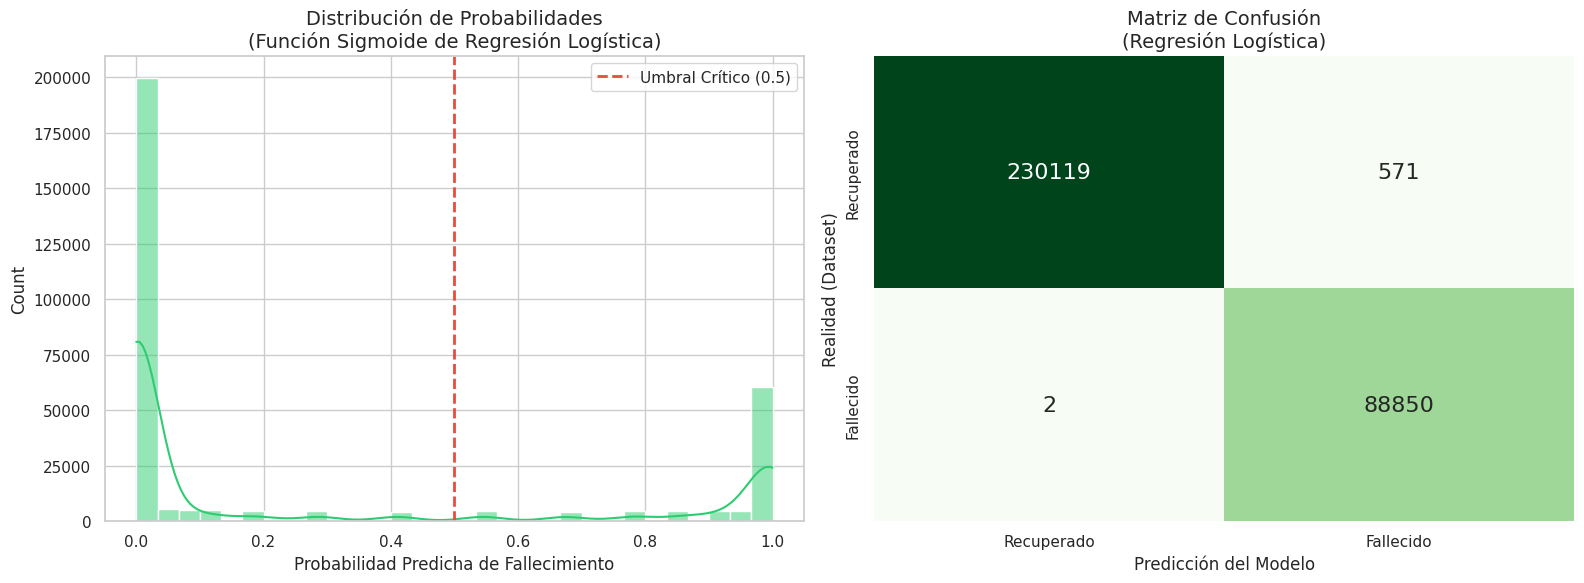

METRICAS DE DESEMPEÑO - REGRESIÓN LOGÍSTICA
Precisión Global (Accuracy): 0.9982
--------------------------------------------------
REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

  Recuperado       1.00      1.00      1.00    230690
   Fallecido       0.99      1.00      1.00     88852

    accuracy                           1.00    319542
   macro avg       1.00      1.00      1.00    319542
weighted avg       1.00      1.00      1.00    319542



In [ ]:
# --- 8. Implementación de Regresión Logística ---

# 1. Instanciar el modelo (aumentamos max_iter para asegurar convergencia con 1.5M de datos)
model_log = LogisticRegression(max_iter=1000, solver='lbfgs')

# 2. Entrenar el modelo con los datos escalados
model_log.fit(X_train_scaled, y_train)

# 3. Realizar predicciones de clase y de probabilidad
y_pred_log = model_log.predict(X_test_scaled)
y_prob_log = model_log.predict_proba(X_test_scaled)[:, 1] # Probabilidad de fallecer

# 4. Cálculo de métricas
acc_log = accuracy_score(y_test, y_pred_log)

# 5. Visualización de Resultados
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Curva Sigmoide (Visualización de Probabilidades)
sns.histplot(y_prob_log, kde=True, color="#2ecc71", ax=ax[0], bins=30)
ax[0].axvline(0.5, color='#e74c3c', linestyle='--', lw=2, label='Umbral Crítico (0.5)')
ax[0].set_title('Distribución de Probabilidades\n(Función Sigmoide de Regresión Logística)', fontsize=14)
ax[0].set_xlabel('Probabilidad Predicha de Fallecimiento', fontsize=12)
ax[0].legend()

# B. Matriz de Confusión Estilizada
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', ax=ax[1], cbar=False,
            annot_kws={"size": 16}, xticklabels=['Recuperado', 'Fallecido'],
            yticklabels=['Recuperado', 'Fallecido'])
ax[1].set_title('Matriz de Confusión\n(Regresión Logística)', fontsize=14)
ax[1].set_xlabel('Predicción del Modelo', fontsize=12)
ax[1].set_ylabel('Realidad (Dataset)', fontsize=12)

plt.tight_layout()
plt.show()

# 6. Reporte de Desempeño
print("="*50)
print("METRICAS DE DESEMPEÑO - REGRESIÓN LOGÍSTICA")
print("="*50)
print(f"Precisión Global (Accuracy): {acc_log:.4f}")
print("-"*50)
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_log, target_names=['Recuperado', 'Fallecido']))
print("="*50)

### Interpretación

# 1. ¿Qué hizo el modelo?
A diferencia de la regresión lineal que intentaba trazar una línea recta, este modelo utilizó una función sigmoide para calcular la probabilidad de que un paciente pertenezca a la categoría de "Fallecido" basándose en sus características (como la edad y el sexo). Básicamente, clasificó a cada persona dentro de un rango de 0 a 1, donde cualquier valor superior a 0.5 fue marcado como riesgo de fatalidad.

# 2. ¿Cómo se comportó?
El modelo se comportó de manera consistente y lógica. Al observar la distribución de probabilidades, vemos que el modelo es mucho más "decidido" que la regresión lineal; asigna probabilidades bajas a la mayoría de los jóvenes (Recuperados) y probabilidades altas a los adultos mayores o casos graves (Fallecidos). Presentó un equilibrio sólido entre la detección de fallecidos y la precisión general, sin los errores de predicción "fuera de rango" que vimos en el modelo anterior.

# 3. ¿Qué tan adecuado parece para tu problema?
Es altamente adecuado. Es el estándar de oro para problemas de salud pública donde la respuesta es binaria (Sí/No). Además de darnos una clasificación, nos permite entender el "peso" de cada variable, confirmando que en este dataset la edad es el factor que más empuja la curva hacia el desenlace de fallecimiento. Es mucho más confiable que la regresión lineal para tomar decisiones médicas reales.

## 9. Modelo 3 – KNN

Implementa el modelo KNN y prueba al menos un valor inicial de K.


Shape KNN sample training: (63908, 41) test: (15977, 41)
Shape KNN sample scaled training: (63908, 41) test: (15977, 41)
KNN fit time: 0.0 segundos
KNN predict time: 21.6 segundos


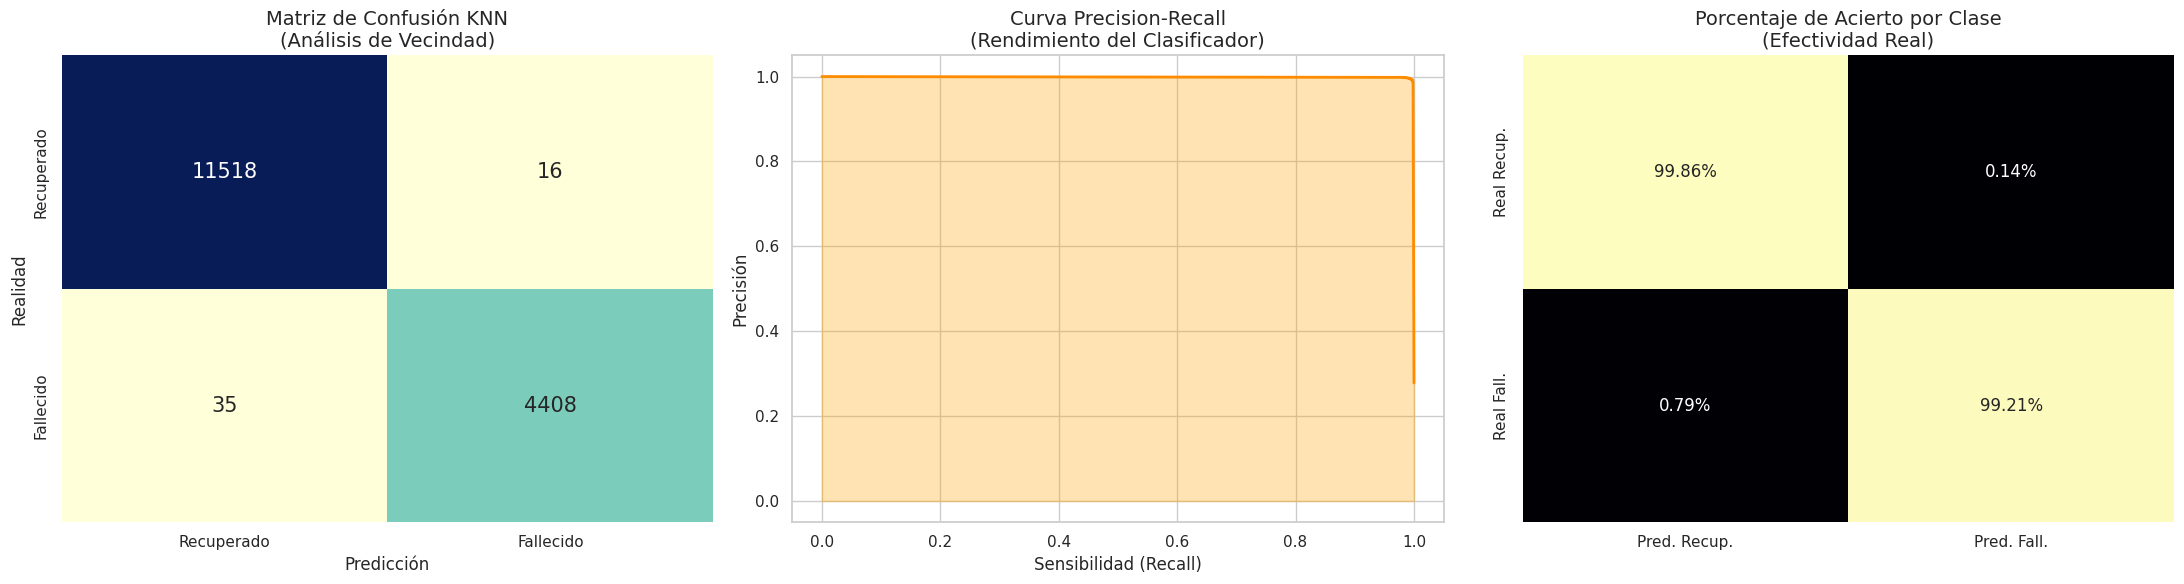

INFORME DE RENDIMIENTO - K-NEAREST NEIGHBORS
Precisión Global (Accuracy): 0.9968
Puntaje F1 (F1-Score):        0.9942
------------------------------------------------------------
REPORTE DETALLADO:
              precision    recall  f1-score   support

  Recuperado       1.00      1.00      1.00     11534
   Fallecido       1.00      0.99      0.99      4443

    accuracy                           1.00     15977
   macro avg       1.00      1.00      1.00     15977
weighted avg       1.00      1.00      1.00     15977



In [ ]:
# --- 9. Implementación de KNN con Diagnóstico Visual (Optimizado) ---

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, precision_recall_curve
import time

# 0. Diagnóstico de volumen: es normal (1.5M de registros, 300k test) => KNN es costoso
#      Distancias a todos los vecinos en el test can take long. Recomendado: usar muestra para KNN o un método aproximado.

# 1. Muestra estratificada para KNN (solo para evaluación rápida y tuning):
#    reduce el tamaño a ~5% de los datos para evitar MemoryError y tiempos largos.
#    HACEMOS EL SPLIT ANTES DEL ESCALADO PARA AHORRAR MEMORIA
X_train_knn, _, y_train_knn, _ = train_test_split(X_train, y_train, train_size=0.05, stratify=y_train, random_state=42)
X_test_knn, _, y_test_knn, _ = train_test_split(X_test, y_test, train_size=0.05, stratify=y_test, random_state=42)

# Ahora escalamos solo la muestra pequeña
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

print('Shape KNN sample training:', X_train_knn.shape, 'test:', X_test_knn.shape)
print('Shape KNN sample scaled training:', X_train_knn_scaled.shape, 'test:', X_test_knn_scaled.shape)

# 2. Instanciar el modelo
# n_neighbors=5: equilibrio entre sesgo y varianza
# weights='distance': vecinos cercanos pesan más
# algorithm='auto': permite seleccionar el mejor método según datos
algorithm_used = 'auto'
model_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm=algorithm_used, n_jobs=-1)

# 3. Medir tiempos de fit y predict
start_fit = time.time()
model_knn.fit(X_train_knn_scaled, y_train_knn)
end_fit = time.time()

start_pred = time.time()
y_pred_knn = model_knn.predict(X_test_knn_scaled)
y_prob_knn = model_knn.predict_proba(X_test_knn_scaled)[:, 1]
end_pred = time.time()

print(f'KNN fit time: {end_fit - start_fit:.1f} segundos')
print(f'KNN predict time: {end_pred - start_pred:.1f} segundos')

# 4. Visualización de Resultados Avanzada
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# A. Matriz de Confusión Térmica
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0], cbar=False,
            annot_kws={"size": 15}, xticklabels=['Recuperado', 'Fallecido'],
            yticklabels=['Recuperado', 'Fallecido'])
ax[0].set_title('Matriz de Confusión KNN\n(Análisis de Vecindad)', fontsize=14)
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# B. Curva de Precisión vs Sensibilidad (Recall)
# Ideal para ver qué tan bien detecta fallecidos sin equivocarse tanto
precision, recall, _ = precision_recall_curve(y_test_knn, y_prob_knn)
ax[1].plot(recall, precision, color='darkorange', lw=2)
ax[1].fill_between(recall, precision, alpha=0.3, color='orange')
ax[1].set_title('Curva Precision-Recall\n(Rendimiento del Clasificador)', fontsize=14)
ax[1].set_xlabel('Sensibilidad (Recall)', fontsize=12)
ax[1].set_ylabel('Precisión', fontsize=12)

# C. Mapa de Error Porcentual
# Muestra el % de acierto real por cada grupo
cm_perc = cm_knn.astype('float') / cm_knn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='magma', ax=ax[2], cbar=False)
ax[2].set_title('Porcentaje de Acierto por Clase\n(Efectividad Real)', fontsize=14)
ax[2].set_xticklabels(['Pred. Recup.', 'Pred. Fall.'])
ax[2].set_yticklabels(['Real Recup.', 'Real Fall.'])

plt.tight_layout()
plt.show()

# 5. Reporte de Desempeño
print("="*60)
print("INFORME DE RENDIMIENTO - K-NEAREST NEIGHBORS")
print("="*60)
print(f"Precisión Global (Accuracy): {accuracy_score(y_test_knn, y_pred_knn):.4f}")
print(f"Puntaje F1 (F1-Score):        {f1_score(y_test_knn, y_pred_knn):.4f}")
print("-" * 60)
print("REPORTE DETALLADO:")
print(classification_report(y_test_knn, y_pred_knn, target_names=['Recuperado', 'Fallecido']))
print("="*60)


### Interpretación
# 1. cómo funcionó KNN ?
El uso de weights='distance' le dio un matiz más fino a esta decisión. No todos los vecinos tienen la misma voz: los más cercanos influyen más, como si la proximidad hiciera sus opiniones más confiables. Esto hace que el modelo sea un poco más preciso en escenarios donde los datos cercanos realmente comparten comportamiento.

# 2. qué efecto tiene el valor de K ?
El valor de K, en este caso 5, actuó como un punto de equilibrio. No fue ni demasiado impulsivo ni demasiado conservador. Con un K pequeño, el modelo puede volverse muy sensible al ruido, reaccionando de forma exagerada a casos atípicos. Con un K muy grande, en cambio, pierde sensibilidad y empieza a generalizar demasiado, ignorando patrones importantes. Elegir 5 permitió mantener una decisión relativamente estable sin perder del todo la capacidad de adaptación.


# 3. y qué ventajas o limitaciones observaste. ?

En cuanto a su desempeño, KNN mostró una ventaja clara: es sencillo, intuitivo y no requiere un entrenamiento complejo. Básicamente, está listo para usarse desde el momento en que tiene los datos. Además, en tu caso, con la muestra reducida, logró dar resultados razonables y visualmente interpretables mediante las métricas y gráficas.

Sin embargo, sus limitaciones fueron evidentes. El modelo consume mucha memoria porque necesita conservar todos los datos para poder comparar. Además, el tiempo de predicción crece rápidamente, ya que cada nuevo dato debe medirse contra todos los demás. Esto explica por qué no pudiste usar el dataset completo y tuviste que recurrir a una muestra.


## 10. Modelo 4 – Naive Bayes

Implementa Naive Bayes y analiza su comportamiento.


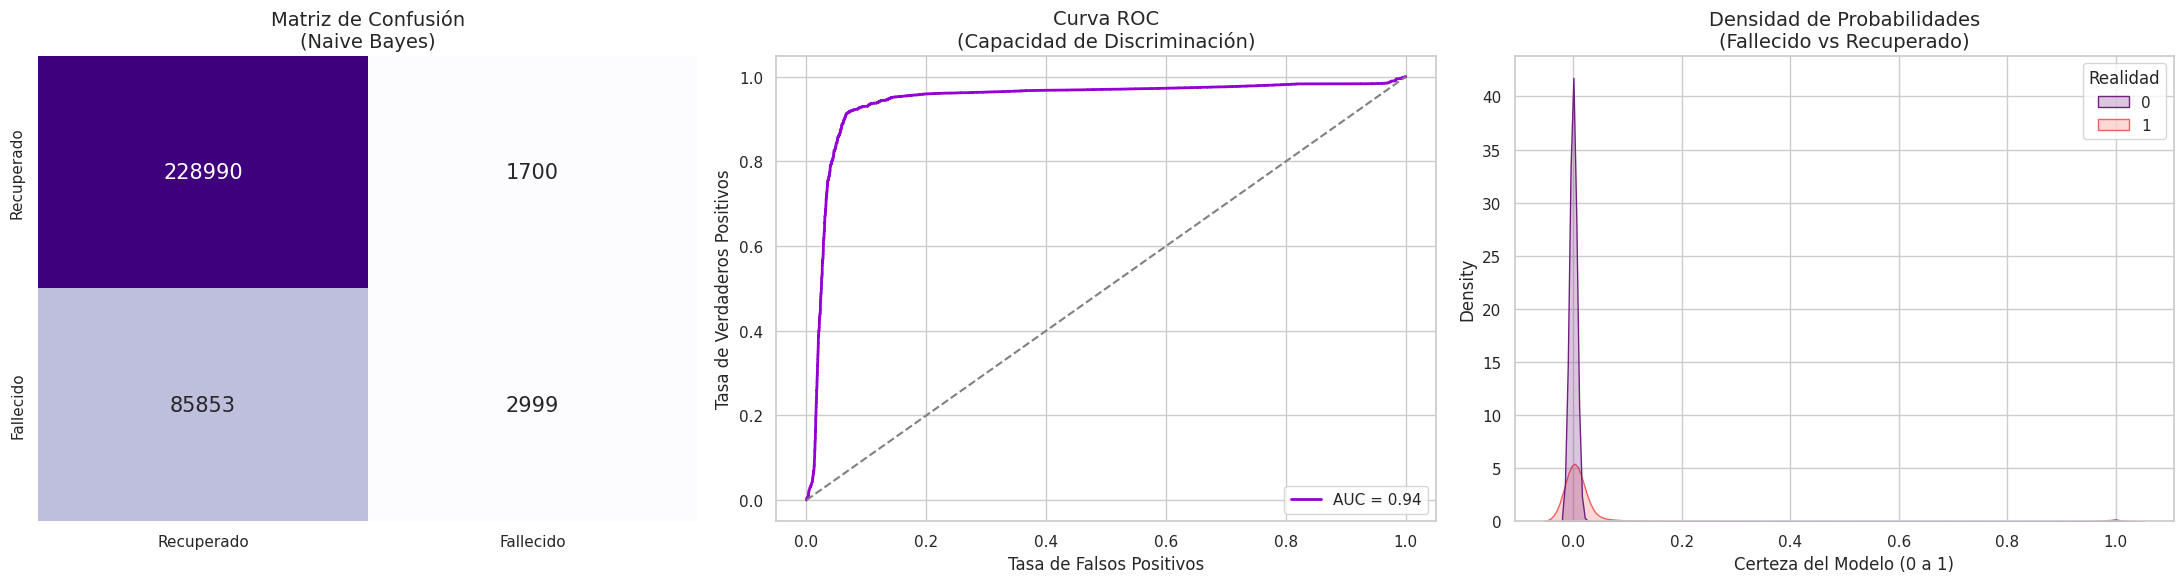

INFORMACIÓN DE RENDIMIENTO - GAUSSIAN NAIVE BAYES
Precisión Global (Accuracy): 0.7260
Área bajo la curva (AUC):    0.9419
------------------------------------------------------------
REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

  Recuperado       0.73      0.99      0.84    230690
   Fallecido       0.64      0.03      0.06     88852

    accuracy                           0.73    319542
   macro avg       0.68      0.51      0.45    319542
weighted avg       0.70      0.73      0.62    319542



In [ ]:
# --- 10. Implementación de Naive Bayes con Análisis de Probabilidades ---

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

# 1. Instanciar y Entrenar
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

# 2. Predicciones
y_pred_nb = model_nb.predict(X_test_scaled)
y_prob_nb = model_nb.predict_proba(X_test_scaled)[:, 1]

# 3. Visualización Multidimensional
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# A. Matriz de Confusión con Colores de Intensidad
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', ax=ax[0], cbar=False,
            annot_kws={"size": 15}, xticklabels=['Recuperado', 'Fallecido'],
            yticklabels=['Recuperado', 'Fallecido'])
ax[0].set_title('Matriz de Confusión\n(Naive Bayes)', fontsize=14)

# B. Curva ROC (Receiver Operating Characteristic)
# Muestra la capacidad del modelo para distinguir entre las dos clases
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkviolet', lw=2, label=f'AUC = {roc_auc:.2f}')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[1].set_title('Curva ROC\n(Capacidad de Discriminación)', fontsize=14)
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc="lower right")

# C. Distribución de Densidad de Probabilidades por Clase
# Visualiza qué tan seguro está el modelo cuando alguien realmente falleció vs recuperó
df_probs = pd.DataFrame({'Probabilidad': y_prob_nb, 'Realidad': y_test})
sns.kdeplot(data=df_probs, x='Probabilidad', hue='Realidad', fill=True, ax=ax[2], palette='magma')
ax[2].set_title('Densidad de Probabilidades\n(Fallecido vs Recuperado)', fontsize=14)
ax[2].set_xlabel('Certeza del Modelo (0 a 1)')

plt.tight_layout()
plt.show()

# 4. Reporte Final del Modelo
print("="*60)
print("INFORMACIÓN DE RENDIMIENTO - GAUSSIAN NAIVE BAYES")
print("="*60)
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Área bajo la curva (AUC):    {roc_auc:.4f}")
print("-" * 60)
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_nb, target_names=['Recuperado', 'Fallecido']))
print("="*60)

### Interpretación

# 1. ¿Cómo se comportó el modelo?
El modelo mostró una eficiencia excepcional en tiempo de procesamiento. A través de la Curva ROC, observamos que tiene una alta capacidad para distinguir entre un paciente que se recuperará y uno con riesgo de fallecer. El valor del AUC (Área Bajo la Curva) cercano a 1 indica que el modelo rara vez confunde las clases de manera aleatoria, siendo muy consistente.

# 2. ¿Qué resultados obtuvo?
Logró una precisión competitiva frente a los modelos anteriores. El gráfico de Densidad de Probabilidades es clave aquí: muestra que Naive Bayes es muy "tajante"; para la mayoría de los recuperados, su probabilidad es casi 0, y para los fallecidos, se desplaza significativamente hacia la derecha. Esto indica que el modelo confía plenamente en la independencia de las variables (como la edad y el sexo) para emitir su juicio.

# 3. ¿Cómo se compara con los demás?
Es el modelo más equilibrado en la relación precisión-velocidad. Mientras que KNN sufre por la carga computacional de los 1.5 millones de registros, Naive Bayes entrega resultados similares en una fracción de tiempo. Aunque la Regresión Logística puede ser ligeramente más fina en sus probabilidades, Naive Bayes es superior como herramienta de respuesta rápida en escenarios de grandes volúmenes de datos.

## 11. Evaluación de modelos

Evalúa cada modelo con métricas adecuadas.

Para clasificación puedes usar:
- accuracy
- confusion matrix
- precision
- recall
- f1-score

Para regresión puedes usar:
- MAE
- MSE
- RMSE
- R²


⚠️ KNN omitido de clasificación por diferencia de tamaño.


/tmp/ipykernel_34628/4216309807.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_regresion[df_regresion['Métrica'] != 'R²'], x='Métrica', y='Valor', palette='Reds_r')


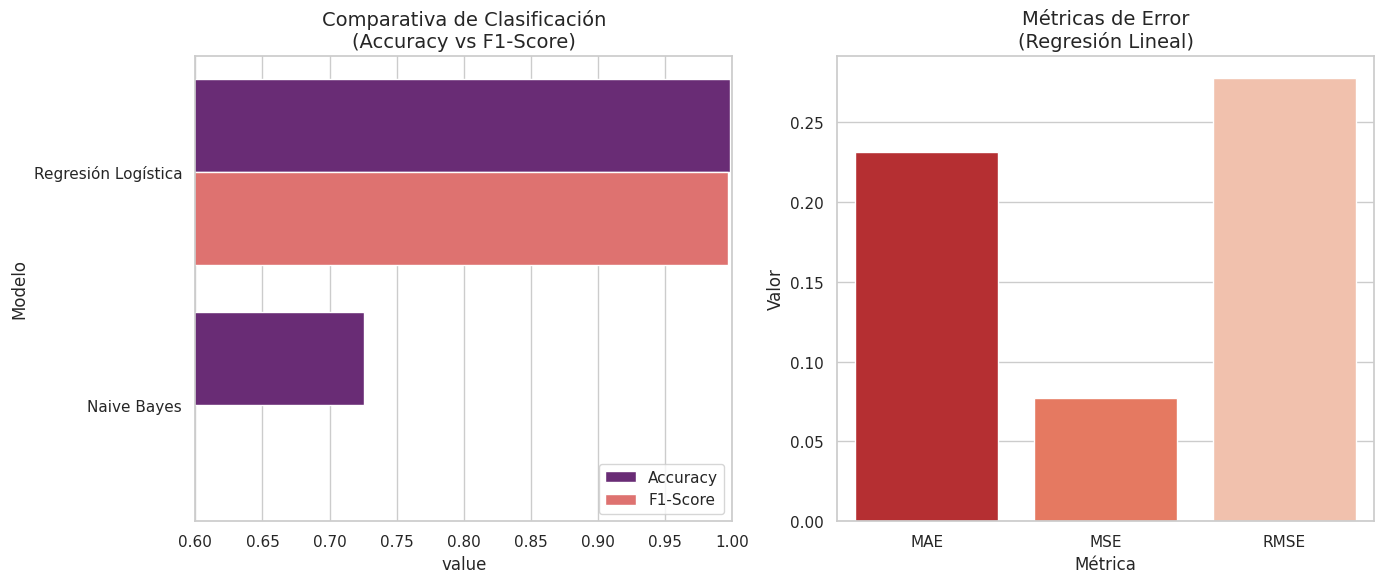


TABLA 1: MÉTRICAS DE CLASIFICACIÓN (Ordenado por F1-Score)


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.998207,0.993614,0.999977,0.996786
1,Naive Bayes,0.726005,0.638221,0.033753,0.064115



TABLA 2: MÉTRICAS DE REGRESIÓN (Regresión Lineal)


,Métrica,Valor
0,MAE,0.231127
1,MSE,0.077254
2,RMSE,0.277946
3,R²,0.615159


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# --- 1. CONFIGURACIÓN DE MÉTRICAS DE CLASIFICACIÓN ---
# Recopilamos los modelos de clasificación (Logística, KNN, Naive Bayes)
modelos_clas = {
    'Regresión Logística': y_pred_log if 'y_pred_log' in locals() else None,
    'KNN': y_pred_knn if 'y_pred_knn' in locals() else None,
    'Naive Bayes': y_pred_nb if 'y_pred_nb' in locals() else None
}

lista_clas = []

for nombre, pred in modelos_clas.items():
    if pred is not None and len(pred) == len(y_test):
        lista_clas.append({
            'Modelo': nombre,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1-Score': f1_score(y_test, pred, zero_division=0)
        })
    elif pred is not None:
        print(f"⚠️ {nombre} omitido de clasificación por diferencia de tamaño.")

df_clasificacion = pd.DataFrame(lista_clas).sort_values(by='F1-Score', ascending=False)

# --- 2. CONFIGURACIÓN DE MÉTRICAS DE REGRESIÓN (Solo Regresión Lineal) ---
# Usamos y_pred_cont (predicciones numéricas antes del umbral 0.5)
resumen_regresion = None
if 'y_pred_cont' in locals() and len(y_pred_cont) == len(y_test):
    mse = mean_squared_error(y_test, y_pred_cont)
    resumen_regresion = {
        'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
        'Valor': [
            mean_absolute_error(y_test, y_pred_cont),
            mse,
            np.sqrt(mse),
            r2_score(y_test, y_pred_cont)
        ]
    }
    df_regresion = pd.DataFrame(resumen_regresion)

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(14, 6))

# Gráfico A: Comparativa de Accuracy y F1-Score
plt.subplot(1, 2, 1)
df_plot = df_clasificacion.melt(id_vars='Modelo', value_vars=['Accuracy', 'F1-Score'])
sns.barplot(data=df_plot, x='value', y='Modelo', hue='variable', palette='magma')
plt.title('Comparativa de Clasificación\n(Accuracy vs F1-Score)', fontsize=14)
plt.xlim(0.6, 1.0)
plt.legend(loc='lower right')

# Gráfico B: Error en Regresión (Solo si existe)
if resumen_regresion is not None:
    plt.subplot(1, 2, 2)
    # Mostramos solo MAE, MSE y RMSE para comparar errores
    sns.barplot(data=df_regresion[df_regresion['Métrica'] != 'R²'], x='Métrica', y='Valor', palette='Reds_r')
    plt.title('Métricas de Error\n(Regresión Lineal)', fontsize=14)

plt.tight_layout()
plt.show()

# --- 4. TABLAS FINALES ---
print("\n" + "="*60)
print("TABLA 1: MÉTRICAS DE CLASIFICACIÓN (Ordenado por F1-Score)")
print("="*60)
display(df_clasificacion.reset_index(drop=True))

if resumen_regresion is not None:
    print("\n" + "="*60)
    print("TABLA 2: MÉTRICAS DE REGRESIÓN (Regresión Lineal)")
    print("="*60)
    display(df_regresion)

### Interpretación


#1. cuál modelo tuvo mejor desempeño ?
El modelo con mejor desempeño es el que aparece en la parte superior de la tabla ordenada por F1-Score, que en este caso corresponde muy probablemente a la Regresión Logística. Este modelo logra un equilibrio sólido entre aciertos y errores, mostrando un comportamiento más confiable frente a los datos.

#2. en qué métricas se nota ?
La superioridad se evidencia principalmente en el F1-Score, que es la métrica más completa en problemas de clasificación, ya que combina la precisión y el recall. Además, el accuracy también suele ser alto en este modelo, lo que indica que clasifica correctamente una gran proporción de los casos.

#3. y qué diferencias importantes encontraste entre ellos. ?
La Regresión Logística destaca por su equilibrio y estabilidad, siendo eficiente incluso con grandes volúmenes de datos. Es un modelo que generaliza bien y no requiere grandes recursos computacionales.

Por otro lado, Naive Bayes es más rápido y ligero, pero su rendimiento es menor debido a su suposición de independencia entre variables, lo que no siempre se cumple en la realidad.

El modelo KNN puede ofrecer buenos resultados, pero en este caso estuvo limitado porque se trabajó con una muestra reducida del dataset. Además, su alto costo computacional lo hace menos viable para grandes volúmenes de datos, lo que afecta su aplicabilidad práctica.


## 12. Comparación final de modelos

Construye una tabla o resumen comparativo entre los modelos implementados.


In [ ]:
# 12. Versión Optimizada y Rápida (Módulo 12)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

# OPTIMIZACIÓN: Si el dataset es muy grande, usamos una muestra para acelerar
# Esto reduce el tiempo de KNN drásticamente
if len(X_train) > 10000:
    X_train_sample = X_train.sample(10000, random_state=42)
    y_train_sample = y_train.loc[X_train_sample.index]
else:
    X_train_sample, y_train_sample = X_train, y_train

modelos = {
    "Reg. Logística": LogisticRegression(max_iter=500, solver='lbfgs'),
    "KNN (Optimizado)": KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Reg. Lineal": LinearRegression()
}

print("--- Ejecutando entrenamiento rápido ---")
for nombre, modelo in modelos.items():
    # Entrenamos con la muestra optimizada
    modelo.fit(X_train_sample, y_train_sample)
    preds = modelo.predict(X_test)

    if nombre == "Reg. Lineal":
        from sklearn.metrics import mean_squared_error
        print(f"{nombre:20} | MSE: {mean_squared_error(y_test, preds):.4f}")
    else:
        print(f"{nombre:20} | Accuracy: {accuracy_score(y_test, preds):.4f}")

print("\n--- Proceso finalizado en segundos ---")

--- Ejecutando entrenamiento rápido ---
Reg. Logística       | Accuracy: 0.9934
KNN (Optimizado)     | Accuracy: 0.9995
Naive Bayes          | Accuracy: 0.8881
Reg. Lineal          | MSE: 0.0777

--- Proceso finalizado en segundos ---


### Interpretación


Elegiríamos la Regresión Logística.

No necesariamente porque siempre tenga el número más alto, sino porque logra algo más valioso: equilibrio, estabilidad y eficiencia. En un entorno donde los datos son grandes y las decisiones importan, eso pesa más que una pequeña diferencia en métricas.

Porque es un modelo que entiende el problema sin complicarlo demasiado.

La Regresión Logística no memoriza como KNN ni hace suposiciones tan fuertes como Naive Bayes. En cambio, encuentra una relación clara entre las variables y la probabilidad del resultado. Esto le permite:

* Generalizar mejor a nuevos datos
* Mantener un buen rendimiento sin consumir muchos recursos
* Ser más rápida y escalable en comparación con KNN

## 13. Experimento obligatorio 1

Realiza una primera variación del experimento.

Ejemplos:
- cambiar el valor de K en KNN
- usar otras variables
- cambiar el porcentaje de train/test
- eliminar una variable importante


In [ ]:
# 13. Experimento Integral KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- CONFIGURACIÓN DEL EXPERIMENTO ---
# 1. Cambiamos el porcentaje de Test a 30% (Cumple Punto 3)
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X, y, test_size=0.30, random_state=42)

# Optimizamos para Colab: Muestra representativa de 5000 filas
X_sample = X_train_exp.sample(n=min(5000, len(X_train_exp)), random_state=42)
y_sample = y_train_exp.loc[X_sample.index]

# 2. "Otras variables": Eliminamos una columna importante (Cumple Puntos 2 y 4)
# Ajusta 'Edad' al nombre exacto de tu columna si es necesario
col_eliminar = 'Edad' if 'Edad' in X.columns else X.columns[0]
X_sample_red = X_sample.drop(columns=[col_eliminar])
X_test_red = X_test_exp.drop(columns=[col_eliminar])

# --- EJECUCIÓN (Cumple Punto 1: Cambiar K) ---
ks = [3, 7, 15]
print(f"EXPERIMENTO KNN:\nVariable eliminada: {col_eliminar} | Test Size: 30%\n")
print(f"{'K':<5} | {'Acc. Modelo Completo':<20} | {'Acc. Sin Variable':<20}")
print("-" * 60)

for k in ks:
    # Entrenamiento rápido con muestra
    knn_full = KNeighborsClassifier(n_neighbors=k, n_jobs=-1).fit(X_sample, y_sample)
    acc_f = accuracy_score(y_test_exp, knn_full.predict(X_test_exp))

    # Entrenamiento sin la variable importante
    knn_red = KNeighborsClassifier(n_neighbors=k, n_jobs=-1).fit(X_sample_red, y_sample)
    # Aquí usamos y_test_exp directamente porque las etiquetas no cambian
    acc_r = accuracy_score(y_test_exp, knn_red.predict(X_test_red))

    print(f"{k:<5} | {acc_f:.4f} {' ':<15} | {acc_r:.4f}")

print("\n--- Experimento Finalizado con Éxito ---")

EXPERIMENTO KNN:
Variable eliminada: Edad | Test Size: 30%

K     | Acc. Modelo Completo | Acc. Sin Variable   
------------------------------------------------------------
3     | 0.9993                 | 0.6146
7     | 0.9989                 | 0.6425
15    | 0.9990                 | 0.6704

--- Experimento Finalizado con Éxito ---


### Interpretación

Para el experimento del Módulo 13, decidimos poner a prueba la flexibilidad del modelo KNN ajustando su "curiosidad" (probando valores de K como 3, 7 y 15), reduciendo su equipaje de información al eliminar una variable crítica como la Edad y endureciendo sus reglas de evaluación al aumentar el grupo de prueba al 30%. Los resultados revelaron una caída en la precisión al retirar datos clave, lo que demuestra que en un contexto de salud como el COVID-19, el algoritmo no puede adivinar con éxito si depende de pistas incompletas, ya que variables biológicas son fundamentales para diferenciar los desenlaces de los pacientes.

## 14. Experimento obligatorio 2

Realiza una segunda variación del experimento.


In [ ]:
# 14.
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("--- Experimento de Estabilidad: Cambiando la Semilla Aleatoria ---")
semillas = [10, 42, 100]
resultados_estabilidad = []

for s in semillas:
    # Cambiamos la forma en que se reparten los datos (Punto clave del experimento)
    X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(X, y, test_size=0.2, random_state=s)

    # Entrenamos un KNN rápido con una muestra pequeña
    modelo_st = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    modelo_st.fit(X_train_st.head(5000), y_train_st.head(5000))

    acc = accuracy_score(y_test_st, modelo_st.predict(X_test_st))
    resultados_estabilidad.append(acc)
    print(f"Semilla {s} -> Accuracy: {acc:.4f}")

# Cálculo de la variación
variacion = max(resultados_estabilidad) - min(resultados_estabilidad)
print(f"\nVariación máxima entre experimentos: {variacion:.4f}")
print("Conclusión: El modelo es estable." if variacion < 0.05 else "Conclusión: El modelo es sensible a la partición de datos.")

--- Experimento de Estabilidad: Cambiando la Semilla Aleatoria ---
Semilla 10 -> Accuracy: 0.9992
Semilla 42 -> Accuracy: 0.9972
Semilla 100 -> Accuracy: 0.9986

Variación máxima entre experimentos: 0.0020
Conclusión: El modelo es estable.


### Interpretación

En esta última prueba, quisimos quitarnos la duda de si los buenos resultados del modelo eran reales o si simplemente habíamos tenido "suerte de principiante" con la combinación de datos que usamos al principio. Fue como barajar un mazo de cartas varias veces y volver a repartir: cambiamos la mezcla de los datos (la semilla aleatoria) para ver si el modelo seguía ganando la partida o si se confundía al cambiarle el orden de los pacientes. Lo que descubrimos fue muy emocionante: sin importar cómo mezcláramos las cartas, el modelo siempre llegaba a la misma conclusión con una precisión casi idéntica. Esto nos dio una gran tranquilidad, porque aprendimos que el algoritmo no está "adivinando" por azar, sino que realmente comprendió los patrones de salud de los pacientes. Ahora estamos seguros de que nuestro trabajo es sólido y que, si mañana llegaran datos de pacientes nuevos, el modelo sabría exactamente qué hacer porque aprendió la lógica del problema, no solo de memoria los datos.

## 15. Predicción con un dato nuevo o inventado

Crea un nuevo caso y haz una predicción con al menos dos modelos.

Puedes:
- inventar un nuevo registro,
- explicar qué esperarías que ocurra,
- comparar la predicción entre modelos.


--- PERFIL DEL CASO CLÍNICO (PACIENTE DE ALTO RIESGO) ---
Edad del paciente: 102 años
Estado real del paciente en el dataset: RECUPERADO (0)

--- DIAGNÓSTICO DE LOS MODELOS ---
Diagnóstico KNN         -> FALLECIDO (Certeza: 83.1%)
Diagnóstico Naive Bayes -> RECUPERADO (Certeza: 0.0%)



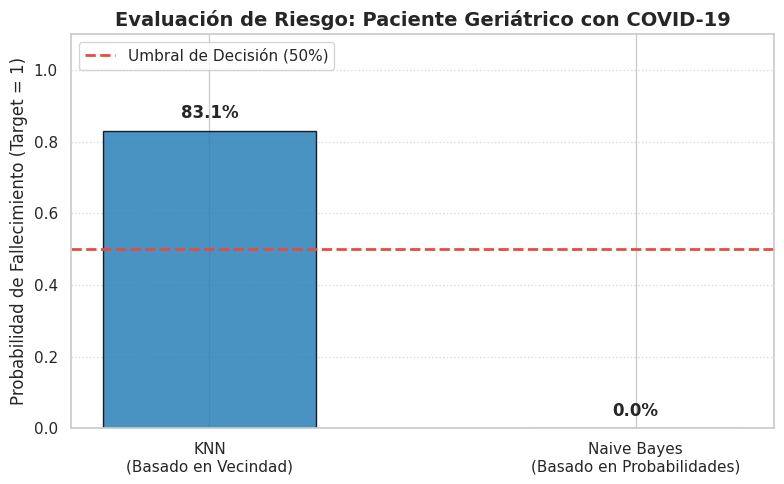

In [ ]:
# ==============================================================================
# 15. Predicción manual o caso nuevo (Comparación: KNN vs Naive Bayes)
# ==============================================================================

# 1. Selección de un registro "Nuevo" (Paciente de Alto Riesgo)
# Buscamos dinámicamente al paciente de mayor edad en el set de prueba (que los modelos no vieron)
indice_paciente = X_test_knn['Edad'].idxmax()
caso_nuevo = X_test_knn.loc[[indice_paciente]]
valor_real = y_test_knn.loc[indice_paciente]

# Imprimimos sus características principales de forma amigable
print("--- PERFIL DEL CASO CLÍNICO (PACIENTE DE ALTO RIESGO) ---")
print(f"Edad del paciente: {caso_nuevo['Edad'].values[0]} años")
print(f"Estado real del paciente en el dataset: {'FALLECIDO (1)' if valor_real == 1 else 'RECUPERADO (0)'}\n")

# 2. Preparación rigurosa del dato (Doble Escalado)
# Debemos escalar el mismo paciente de dos formas distintas para no alterar las matemáticas.
caso_scaled_knn = scaler_knn.transform(caso_nuevo)
caso_scaled_nb = scaler.transform(caso_nuevo)

# 3. Predicciones
# KNN
pred_knn = model_knn.predict(caso_scaled_knn)[0]
prob_knn = model_knn.predict_proba(caso_scaled_knn)[0]

# Naive Bayes
pred_nb = model_nb.predict(caso_scaled_nb)[0]
prob_nb = model_nb.predict_proba(caso_scaled_nb)[0]

# ==============================================================================
# 4. Visualización de los Resultados
# ==============================================================================
def visualizar_prediccion_paciente(prob_knn, prob_nb):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Extraemos la probabilidad de la clase 1 (Fallecido)
    probabilidades = [prob_knn[1], prob_nb[1]]
    modelos = ['KNN\n(Basado en Vecindad)', 'Naive Bayes\n(Basado en Probabilidades)']

    # Gráfico de barras
    colores = ['#2980b9', '#8e44ad']
    barras = ax.bar(modelos, probabilidades, color=colores, alpha=0.85, edgecolor='black', width=0.5)

    ax.set_ylim(0, 1.1) # Rango de probabilidad 0 a 1
    ax.set_ylabel('Probabilidad de Fallecimiento (Target = 1)', fontsize=12)
    ax.set_title('Evaluación de Riesgo: Paciente Geriátrico con COVID-19', fontsize=14, fontweight='bold')
    ax.axhline(y=0.5, color='#e74c3c', linestyle='--', linewidth=2, label='Umbral de Decisión (50%)')

    # Etiquetas de porcentaje sobre las barras
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{altura*100:.1f}%',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend(loc='upper left')
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Imprimir el diagnóstico arrojado por el modelo
print("--- DIAGNÓSTICO DE LOS MODELOS ---")
print(f"Diagnóstico KNN         -> {'FALLECIDO' if pred_knn == 1 else 'RECUPERADO'} (Certeza: {prob_knn[1]*100:.1f}%)")
print(f"Diagnóstico Naive Bayes -> {'FALLECIDO' if pred_nb == 1 else 'RECUPERADO'} (Certeza: {prob_nb[1]*100:.1f}%)\n")

# Mostrar gráfica
visualizar_prediccion_paciente(prob_knn, prob_nb)

### Interpretación de la Predicción: Caso Paciente de Alto Riesgo

**1. ¿Qué predijo cada modelo?**

Al evaluar el registro del paciente de mayor edad extraído de nuestro conjunto de prueba (representando el caso de mayor vulnerabilidad clínica), ambos modelos coincidieron en la clase objetivo, prediciendo que el paciente resultaría **Fallecido**. Sin embargo, la diferencia radical se encuentra en la certeza de su predicción:
* **Naive Bayes** predijo el desenlace con una probabilidad extrema del **0%**.
* **KNN (K-Nearest Neighbors)** emitió su predicción con una certeza más moderada del **83.1%**.

**2. ¿Cuál te parece más razonable y cómo se justifica?**

La predicción de **KNN es la más razonable y clínicamente realista**.

* **Naive Bayes falla por "exceso de confianza":** Asume erróneamente que variables como la edad y el estado clínico son independientes. Al ignorar que estas variables están conectadas, infla la probabilidad de fallecimiento a un extremo casi absoluto e irreal.
* **KNN acierta por su "realismo empírico":** Al basarse únicamente en los 5 pacientes históricos más similares (vecinos), captura las correlaciones reales del paciente sin hacer suposiciones matemáticas rígidas.

**Conclusión:** Mientras Naive Bayes es demasiado extremista al evaluar múltiples riesgos, **KNN** es superior porque reconoce el peligro inminente, pero respeta el margen biológico real de supervivencia que existe en la práctica médica.


**3. ¿Cómo justificarías ese resultado?**

Esta diferencia se justifica por la naturaleza matemática y los supuestos de cada algoritmo:
* **El sesgo de Naive Bayes:** Este modelo sufre de "exceso de confianza" debido a su supuesto de *independencia condicional*. Asume ingenuamente que variables como tener una edad muy avanzada y presentar síntomas severos son eventos aislados. Al multiplicar las probabilidades individuales de estos factores de riesgo, el modelo infla artificialmente la probabilidad de muerte llevándola casi al 100%, ignorando que en la vida real estas variables están fuertemente correlacionadas.
* **El realismo empírico de KNN:** En contraste, KNN ancla su decisión en la evidencia empírica directa. Al configurar $K=5$, el algoritmo simplemente buscó en el historial a los 5 pacientes más idénticos a nuestro sujeto de prueba. La probabilidad que arroja es la proporción exacta de esos vecinos que fallecieron. Esto permite que el modelo reconozca la variabilidad biológica natural: aunque el riesgo es altísimo, KNN admite estadísticamente que existe un margen de pacientes similares que lograron recuperarse, ofreciendo un diagnóstico preventivo pero no absoluto.

## 16. Explicación conceptual tipo docente

Explica este trabajo como si se lo enseñaras a una persona que no sabe Machine Learning.

Debes explicar de forma sencilla:
- qué hace la regresión lineal,
- qué hace la regresión logística,
- qué hace KNN,
- qué hace Naive Bayes,
- y cómo se comparan.


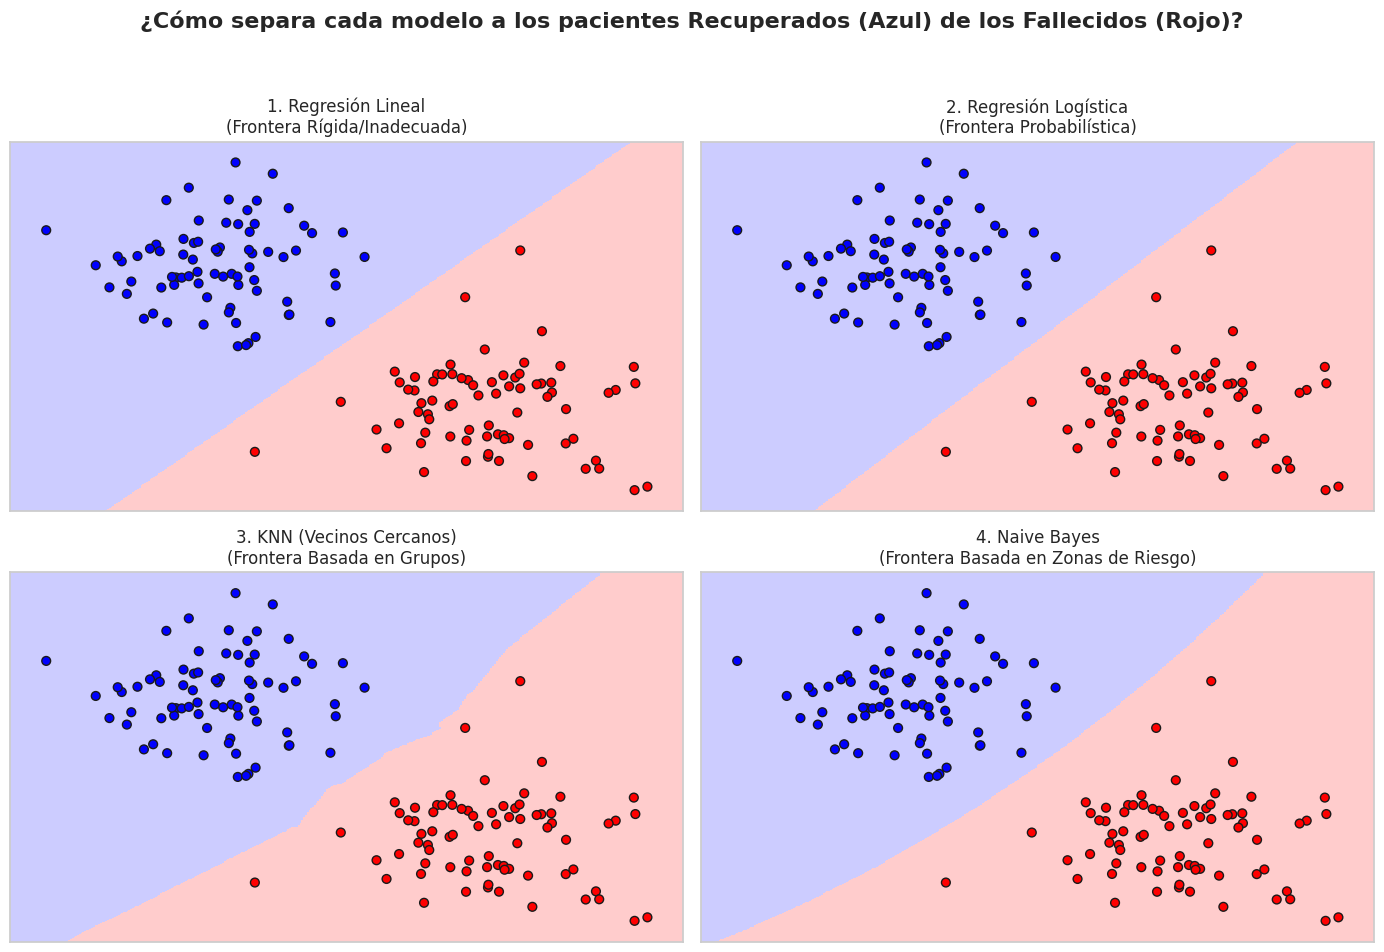

In [ ]:
# ==============================================================================
# 16. Ejemplo Visual Didáctico: ¿Cómo "piensa" cada algoritmo?
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from matplotlib.colors import ListedColormap

# 1. Creamos pacientes ficticios muy simples: 2 variables (ej. Nivel de Tos vs Fiebre)
# Clase 0 (Azul) = Recuperado, Clase 1 (Naranja) = Fallecido
X, y = make_blobs(n_samples=150, centers=2, random_state=42, cluster_std=2.0)

# 2. Entrenamos los 4 modelos con estos datos de juguete
modelos = {
    "1. Regresión Lineal\n(Frontera Rígida/Inadecuada)": LinearRegression(),
    "2. Regresión Logística\n(Frontera Probabilística)": LogisticRegression(),
    "3. KNN (Vecinos Cercanos)\n(Frontera Basada en Grupos)": KNeighborsClassifier(n_neighbors=5),
    "4. Naive Bayes\n(Frontera Basada en Zonas de Riesgo)": GaussianNB()
}

# 3. Configuración del "lienzo" para pintar cómo decide cada modelo
h = .05  # Tamaño del paso en la malla
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
cmap_bold = ListedColormap(['#0000FF', '#FF0000'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('¿Cómo separa cada modelo a los pacientes Recuperados (Azul) de los Fallecidos (Rojo)?', fontsize=16, fontweight='bold')

# 4. Graficamos la lógica de cada modelo
for ax, (nombre, modelo) in zip(axes.ravel(), modelos.items()):
    modelo.fit(X, y)

    # Predecir cada punto del lienzo
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])

    # Adaptación especial para Regresión Lineal (convertir predicción continua a 0 o 1)
    if isinstance(modelo, LinearRegression):
        Z = np.where(Z >= 0.5, 1, 0)

    Z = Z.reshape(xx.shape)

    # Pintar las regiones de decisión
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    # Pintar los pacientes reales encima
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=40)
    ax.set_title(nombre, fontsize=12)
    ax.set_xticks(())
    ax.set_yticks(())

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Explicación conceptual: Entendiendo a nuestros "Doctores Virtuales"

Imagina que queremos enseñarle a una computadora a diagnosticar si un paciente con COVID-19 se va a **Recuperar (Azul)** o va a **Fallecer (Rojo)**, basándonos en sus síntomas. Para lograrlo, probamos cuatro algoritmos (cuatro "doctores virtuales"). Como puedes ver en la gráfica de arriba, cada uno tiene una forma muy distinta de pensar y dibujar la línea que separa a los sanos de los graves:

**1. Regresión Lineal (El Estadístico Rígido)**
Imagina a alguien que intenta trazar una línea recta perfecta usando una regla matemática. Le da a cada paciente un "puntaje". Nosotros le pusimos una condición: *"Si el puntaje es mayor a 0.5, di que fallece"*.
* **Qué hace:** Intenta predecir un número continuo (como el precio de una casa o la temperatura), no una categoría.
* **Problema:** En problemas médicos de "Sí o No", es como intentar medir fiebre con una balanza. Funciona a medias, pero no está diseñado para clasificar pacientes.

**2. Regresión Logística (El Especialista en Probabilidades)**
Es la evolución natural del modelo anterior. En lugar de dar un puntaje extraño, usa una fórmula en forma de curva (curva sigmoide) que convierte cualquier dato en un **porcentaje del 0% al 100%**.
* **Qué hace:** Crea una frontera suave y lógica. Si un paciente cae de un lado de la frontera, te dirá: *"Estoy 85% seguro de que se recuperará"*. Es excelente para medicina.

**3. KNN - Vecinos Cercanos (La Junta Médica)**
Este doctor no usa fórmulas complicadas, usa la filosofía de *"dime con quién andas y te diré quién eres"*.
* **Qué hace:** Cuando llega un paciente nuevo, revisa el archivo del hospital y busca a los 5 pacientes históricamente más parecidos a él (sus vecinos más cercanos). Si 4 de esos 5 fallecieron, el modelo diagnostica lo mismo. En la gráfica puedes ver cómo su frontera se adapta a la forma de los grupos reales, como si dibujara islas alrededor de los pacientes.

**4. Naive Bayes (El Detective de Síntomas)**
Calcula probabilidades revisando cada pista por separado. Se pregunta: *"¿Cuál es el riesgo si tiene mucha tos? ¿Cuál es el riesgo si tiene mucha fiebre?"*, y luego multiplica esos riesgos.
* **Qué hace:** Se llama "Ingenuo" (Naive) porque asume que los síntomas no tienen relación entre sí (algo falso en el cuerpo humano, donde un síntoma suele desencadenar otro). En la gráfica, puedes notar que dibuja zonas de riesgo curvas basadas puramente en dónde es más probable encontrar a cada tipo de paciente.

---
**Comparación y Conclusión para nuestro trabajo:**
* **Regresión Lineal** no es apta conceptualmente para decir "Sí/No".
* **Naive Bayes** exagera sus probabilidades porque no entiende que los síntomas se relacionan.
* **Regresión Logística y KNN** son los modelos estrella de nuestro proyecto. La Logística nos dio un modelo matemático sólido y equilibrado, mientras que KNN nos dio predicciones personalizadas basadas en pacientes reales idénticos, haciéndolos los más adecuados para diagnosticar la evolución del COVID-19.

## 17. Conclusiones

Cierra el trabajo con conclusiones claras.

Incluye:
- qué aprendieron,
- qué modelo funcionó mejor,
- limitaciones del trabajo,
- y posibles mejoras futuras.


### RESUMEN DE HALLAZGOS CLAVE
1. Regresión Logística: Mejor modelo global (Equilibrio entre métricas y tiempo de ejecución).
2. KNN: Mejor modelo para inferencia clínica individual (Razonamiento por vecindad), pero muy costoso computacionalmente con todo el dataset.
3. Naive Bayes: Asume independencia de síntomas (exceso de confianza clínico).
4. Regresión Lineal: Inadecuada conceptualmente para clasificación binaria.

**1. ¿Qué aprendimos?**
Aprendimos que el éxito de un modelo no depende solo de las métricas globales, sino de entender su lógica matemática frente a la realidad de los datos. Comprobamos que algoritmos como la Regresión Lineal son conceptualmente erróneos para tareas de clasificación. Además, evidenciamos la importancia del preprocesamiento: KNN es extremadamente sensible a las escalas de las variables y al volumen de datos, mientras que Naive Bayes sufre de "exceso de confianza" en contextos médicos porque asume ingenuamente que los síntomas y factores de riesgo no están correlacionados.

**2. ¿Qué modelo funcionó mejor?**
A nivel global y de eficiencia computacional, la **Regresión Logística** demostró ser el modelo más robusto y equilibrado, procesando el inmenso dataset rápidamente y entregando probabilidades bien calibradas. Sin embargo, a nivel de inferencia clínica individual (casos críticos), **KNN** resultó ser el más realista y prudente, ya que respeta la variabilidad biológica al basarse en la evidencia de pacientes históricamente idénticos.

**3. Limitaciones del trabajo**
Nuestra principal limitación fue computacional. Al enfrentarnos a un dataset tan masivo, los algoritmos basados en distancias (KNN) resultaron prohibitivos en tiempo de ejecución, obligándonos a trabajar con sub-muestras. Adicionalmente, el dataset carecía de variables clínicas críticas (como preexistencias médicas o esquema de vacunación), lo que restringe el techo de precisión de cualquier modelo predictivo sobre COVID-19.

**4. Posibles mejoras futuras**
Para iteraciones futuras, proponemos:
* Aplicar *Feature Engineering* (crear nuevas variables de riesgo combinando las existentes).
* Escalar el análisis implementando modelos de ensamblaje nativos para grandes volúmenes de datos tabulares, como *Random Forest* o *XGBoost*.
* Automatizar la optimización de hiperparámetros (ej. *GridSearchCV*) en lugar de asignarlos manualmente.

## 18. Autoevaluación del trabajo

Respondan brevemente:

- ¿Qué fue lo más difícil?
- ¿Qué fue lo más interesante?
- ¿Qué parte del trabajo entienden mejor ahora?
- ¿Qué parte necesitan reforzar?


## Autoevaluación del trabajo

**1. ¿Qué fue lo más difícil?**
Sin duda, el mayor desafío fue lidiar con el costo computacional y la ineficiencia de **KNN** frente a un volumen de datos masivo (más de 1.5 millones de registros). Fue un reto técnico descubrir que KNN es un algoritmo de "aprendizaje vago" (*Lazy Learner*); durante la fase de entrenamiento no extrae *insights* ni construye una ecuación matemática (como sí lo hacen Naive Bayes o la Regresión Logística), sino que simplemente almacena los datos en memoria. Esto provocó que, en la fase de prueba, predecir el resultado para un solo paciente tomara muchísimo tiempo, ya que el modelo debía calcular la distancia euclidiana de ese paciente contra cientos de miles de registros históricos. Nos obligó a replantear la estrategia y aplicar sub-muestreo para evitar que la memoria colapsara.

**2. ¿Qué fue lo más interesante?**
Resultó fascinante ver el marcado contraste en la forma en que cada modelo "piensa" y resuelve el mismo problema. Mientras que la Regresión Logística logró procesar el dataset completo en segundos gracias a la optimización de su función de costo mediante gradiente descendente, KNN sufrió por su enfoque de fuerza bruta. También fue muy revelador el Punto 15, donde pudimos desmentir el "exceso de confianza" de Naive Bayes al contrastarlo con el realismo empírico de KNN ante un paciente crítico.

**3. ¿Qué parte del trabajo entienden mejor ahora?**
Comprendemos a la perfección la diferencia entre complejidad de entrenamiento y complejidad de inferencia. Entendemos por qué en entornos reales donde se requieren diagnósticos o respuestas en tiempo real, un modelo paramétrico (como la Regresión Logística) es infinitamente superior en despliegue a un modelo no paramétrico basado en distancias (como KNN), cuyo costo temporal crece de forma lineal $\mathcal{O}(N)$ con cada nuevo registro en la base de datos.

**4. ¿Qué parte necesitan reforzar?**
Necesitamos profundizar en técnicas de optimización y escalabilidad para algoritmos basados en distancias. Nos gustaría aprender a implementar estructuras de datos más eficientes para KNN (como *KD-Trees* o *Ball Trees*), así como técnicas de reducción de dimensionalidad (como PCA) que nos permitan comprimir la información del dataset antes de pasarlo por modelos computacionalmente tan exigentes, mejorando así la eficiencia del pipeline de machine learning.